In [21]:
import pandas as pd

In [22]:
dataset_full = pd.read_csv("./cars_dataset.csv", encoding="cp1252")

filtered = dataset_full[
    dataset_full["Company Names"].isin(
        [
            "TOYOTA",
            "VOLVO",
            "Toyota",
            "Volvo",
            "BMW",
            "Tesla",
            "Volkswagen",
        ]
    )
]

df_sample = filtered.sample(n=12, random_state=123)

In [23]:
df = df_sample.drop(columns=["Engines", "Fuel Types"])

cols = [
    "CC/Battery Capacity",
    "HorsePower",
    "Total Speed",
    "Performance(0 - 100 )KM/H",
    "Cars Prices",
    "Seats",
    "Torque"
]

df[cols] = df[cols].apply(
    lambda col: col.astype(str)
    .str.replace(',', '')
    .str.extract(r'(\d+\.?\d*)')[0]
).astype(float)

int_cols = cols.copy()
int_cols.remove("Performance(0 - 100 )KM/H")

df[int_cols] = df[int_cols].astype(int)
df.reset_index(drop=True, inplace=True)


In [24]:
df

,Company Names,Cars Names,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Seats,Torque
0,Volkswagen,Golf 4MOTION,1968,150,250,4.9,40000,5,400
1,Volvo,Volvo VNR,12800,400,110,17.0,95000,2,1800
2,TOYOTA,GR COROLLA,1618,300,230,5.0,36995,5,370
3,BMW,M550i XDRIVE,4395,523,250,3.6,78000,5,650
4,TOYOTA,INNOVA HYCROSS,1987,184,165,9.5,40000,7,250
5,Volkswagen,Passat Hybrid,1395,215,210,7.4,32000,5,330
6,Tesla,Model X,100,670,250,3.8,98490,7,967
7,Volkswagen,Jetta Hybrid,1395,170,210,8.6,28000,5,250
8,Volvo,Volvo FMX,13000,500,110,16.5,110000,2,2500
9,Volkswagen,Passat,1984,150,210,7.8,25000,5,250


# 2.1


In [25]:
from pulp import *

prefs = [
    (6, 3, '>'),
    (3, 2, '>'),
    (2, 0, '>'),
    (6, 8, '>'),
    (8, 1, '>'),
    (1, 11, '>'),
    (4, 7, '>'),
    (7, 5, '>'),
    (2, 4, '>'),
    (0, 9, '>'),
    (5, 9, '>'),
    (9, 10, '>'),
    (3, 0, '>'),
    (6, 2, '>'),
    (8, 11, '>'),
    (3, 0, '~'), 
    (2, 6, '>') #added cycle
]

gain = ['CC/Battery Capacity', 'HorsePower',
       'Total Speed',  'Seats',
       'Torque']

cost = ['Performance(0 - 100 )KM/H', 'Cars Prices']
criteria = gain + cost


In [26]:

def generate_levels(min_val, max_val, gamma):
    return [
        min_val + (j / (gamma - 1)) * (max_val - min_val)
        for j in range(gamma)
    ]

criterion_values = {}
gamma = 4

for c in criteria:
    min_val = df[c].min()
    max_val = df[c].max()
    criterion_values[c] = generate_levels(min_val, max_val, gamma)

In [27]:
def solve(forbidden=[]):
    prob = LpProblem("UTA", LpMinimize)

    u = {}
    # marginal utilities
    for c in criteria:
        u[c] = {}
        for val in criterion_values[c]:
            u[c][val] = LpVariable(f"u_{c}_{val}", 0, 1)

    # monotonicity
    for c in criteria:
        vals = criterion_values[c]
        for i in range(len(vals)-1):
            if c in cost:
                prob += u[c][vals[i]] >= u[c][vals[i+1]]
            else:
                prob += u[c][vals[i]] <= u[c][vals[i+1]]

    #normalization
    for c in criteria:
        vals = criterion_values[c]
        if c in cost:
            prob += u[c][vals[-1]] == 0
        else:
            prob += u[c][vals[0]] == 0

    # weight constraints
    weights = {}
    for c in criteria:
        vals = criterion_values[c]
        if c in cost:
            weights[c] = u[c][vals[0]]
        else:
            weights[c] = u[c][vals[-1]]
        prob += weights[c] <= 0.5
        prob += weights[c] >= 0.1


    prob += lpSum(weights[c] for c in criteria) == 1

    def marginal_utility(c, val):
        vals = sorted(criterion_values[c])

        for j in range(len(vals) - 1):
            xj = vals[j]
            xj1 = vals[j+1]

            if xj <= val <= xj1:
                return (
                    u[c][xj] +
                    (val - xj) / (xj1 - xj) *
                    (u[c][xj1] - u[c][xj])
                )

        return u[c][vals[-1]]


    def utility(i):
        return lpSum(
            marginal_utility(c, df.loc[i, c])
            for c in criteria
        )

    epsilon = 0.01
    M = 10

    y = {}

    for k, (a, b, rel) in enumerate(prefs):
        y[k] = LpVariable(f"y_{k}", cat="Binary")

        if rel == '>':
            prob += utility(a) >= utility(b) + epsilon - M * y[k]

        elif rel == '~':
            prob += utility(a) >= utility(b) - M * y[k]
            prob += utility(a) <= utility(b) + M * y[k]
        
    for forbidden_variables in forbidden:
        prob += lpSum([y[k] for k in forbidden_variables]) <= len(forbidden_variables) - 1

    prob += lpSum(y[k] for k in y)

    #prob.solve(PULP_CBC_CMD(msg=0))
    prob.solve(GLPK_CMD(path="/opt/homebrew/bin/glpsol", msg=0)) #for mac
    return prob, y, criteria, weights, u


In [28]:
def print_results(prob, y, criteria, weights):
    print("Status: ", LpStatus[prob.status])
    
    print("Violated constraints:")
    violated = []
    for k in y:
        if value(y[k]) == 1:
            print(f"Removed: {prefs[k]}")
            violated.append(k)
            
    print("Consistent preference subset:")
    for k in range(len(prefs)):
        if k not in violated:
            print(prefs[k])

    print("Weights:")
    for c in criteria:
        print(c, round(value(weights[c]),3))
    


In [29]:
res = solve()
prob, y, criteria, weights, u = res
print_results(prob, y, criteria, weights)


violated = [k for k in y if value(y[k]) == 1]
consistent_prefs = [prefs[k] for k in range(len(prefs)) if k not in violated] # for 2.2


Status:  Optimal
Violated constraints:
Removed: (5, 9, '>')
Removed: (3, 0, '~')
Removed: (2, 6, '>')
Consistent preference subset:
(6, 3, '>')
(3, 2, '>')
(2, 0, '>')
(6, 8, '>')
(8, 1, '>')
(1, 11, '>')
(4, 7, '>')
(7, 5, '>')
(2, 4, '>')
(0, 9, '>')
(9, 10, '>')
(3, 0, '>')
(6, 2, '>')
(8, 11, '>')
Weights:
CC/Battery Capacity 0.1
HorsePower 0.275
Total Speed 0.116
Seats 0.1
Torque 0.1
Performance(0 - 100 )KM/H 0.172
Cars Prices 0.137


The model clearly emphasizes HorsePower and Performance (0–100 km/h), indicating that DM preferences are strongly driven by those metrics.
CC/Battery, Seats, and Torque have smaller weights, suggesting they play a minor role in decision-making.

There are some inconsistencies other than the cycle - (5, 9, '>'), (3, 0, '~'), it might indicate there's some conflicting information or not enough breaking points

In [30]:
import matplotlib.pyplot as plt

def plot_criterion(prob, u, criterion, criterion_values, utility_min=0, utility_max=0.5):
    x_vals = criterion_values[criterion]
    y_vals = [u[criterion][v].varValue for v in x_vals]

    plt.figure(figsize=(8, 6))
    plt.plot(
        x_vals,
        y_vals,
        marker='o',
        linestyle='-',
        label=fr'$u(g_{{{criterion}}})$'
    )
    plt.xlabel(fr'$g_{{{criterion}}}$')
    plt.ylabel(fr'$u(g_{{{criterion}}})$')
    plt.title(f'Partial utility function for criterion {criterion}')
    plt.xticks(x_vals)
    plt.ylim(utility_min, utility_max)
    plt.grid(True)
    plt.legend()
    plt.show()

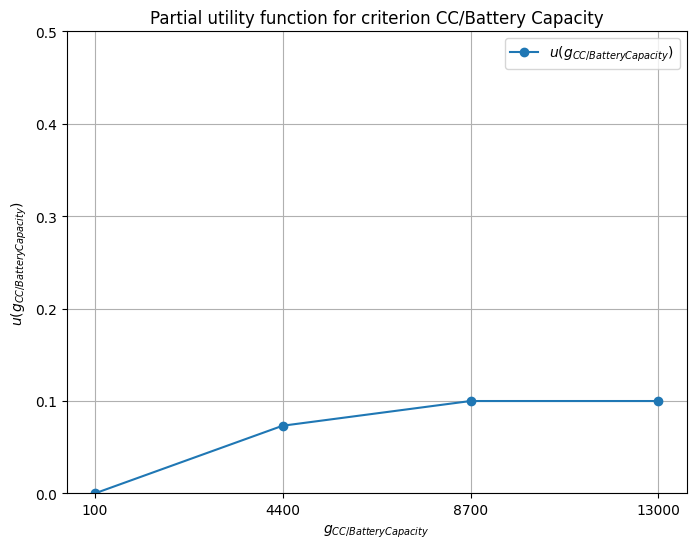

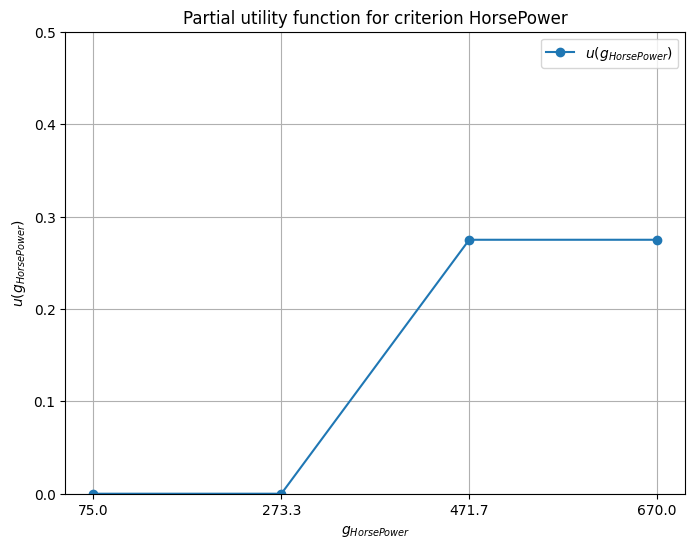

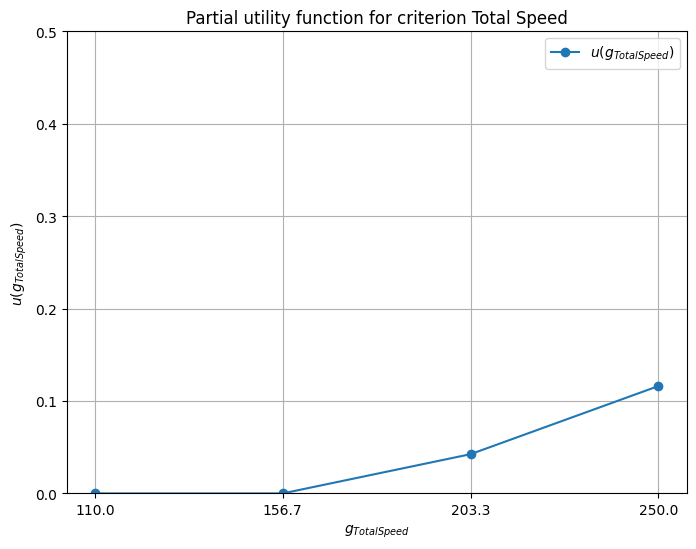

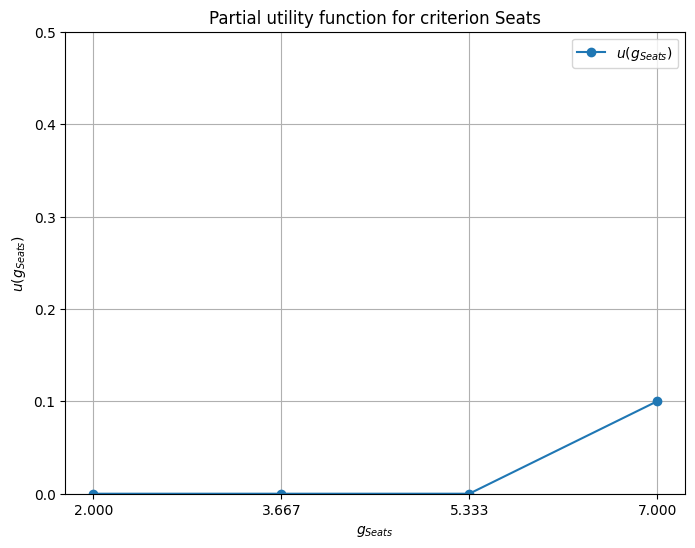

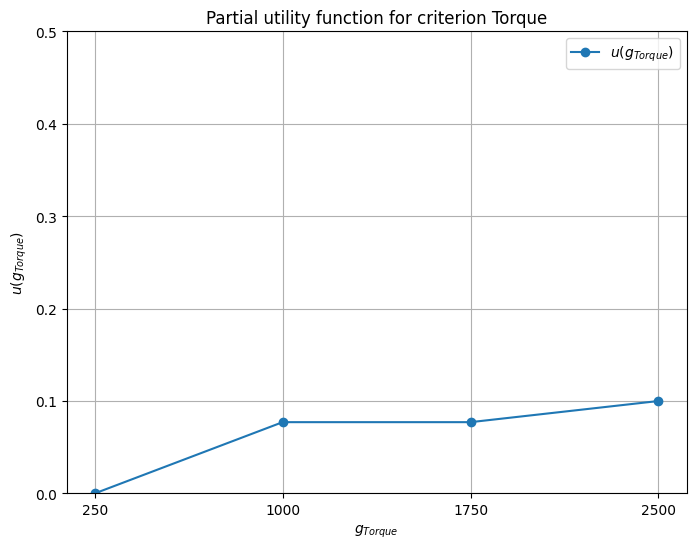

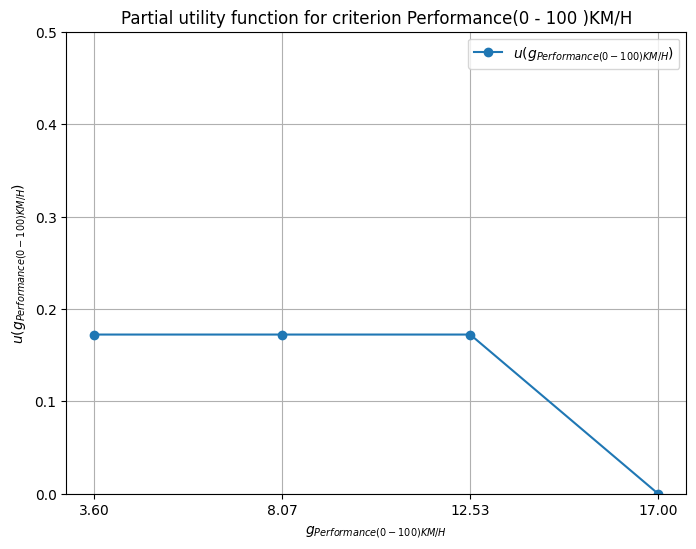

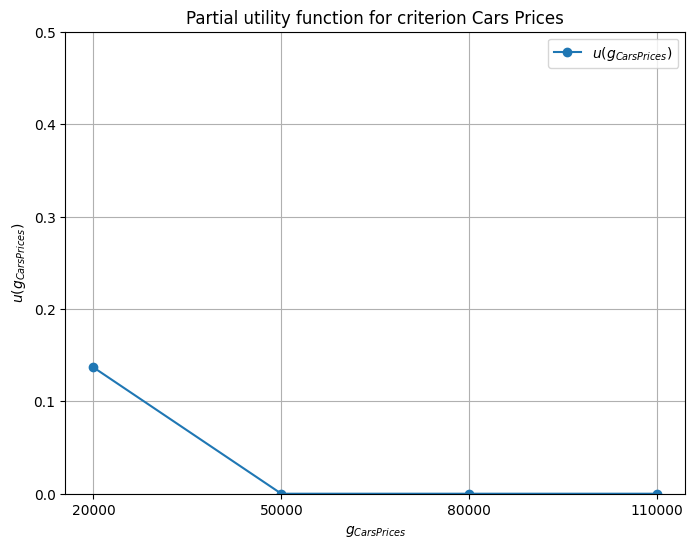

In [31]:
for criterion in criteria:
    plot_criterion(prob, u, criterion, criterion_values)

most marginal utility functions are flat over large ranges, but some have distinct jumps at critical points, which reflect thresholds where performance or preference changes noticeably.

In [32]:
forbidden = []
while True:
    res = solve(forbidden)
    prob, y, criteria, weights, u = res
    if LpStatus[prob.status] != "Optimal":
        break
    forbidden.append([k for k in y if value(y[k]) == 1])
    print(forbidden)
    print_results(prob, y, criteria, weights)

[[10, 15, 16]]
Status:  Optimal
Violated constraints:
Removed: (5, 9, '>')
Removed: (3, 0, '~')
Removed: (2, 6, '>')
Consistent preference subset:
(6, 3, '>')
(3, 2, '>')
(2, 0, '>')
(6, 8, '>')
(8, 1, '>')
(1, 11, '>')
(4, 7, '>')
(7, 5, '>')
(2, 4, '>')
(0, 9, '>')
(9, 10, '>')
(3, 0, '>')
(6, 2, '>')
(8, 11, '>')
Weights:
CC/Battery Capacity 0.1
HorsePower 0.275
Total Speed 0.116
Seats 0.1
Torque 0.1
Performance(0 - 100 )KM/H 0.172
Cars Prices 0.137
[[10, 15, 16], [7, 15, 16]]
Status:  Optimal
Violated constraints:
Removed: (7, 5, '>')
Removed: (3, 0, '~')
Removed: (2, 6, '>')
Consistent preference subset:
(6, 3, '>')
(3, 2, '>')
(2, 0, '>')
(6, 8, '>')
(8, 1, '>')
(1, 11, '>')
(4, 7, '>')
(2, 4, '>')
(0, 9, '>')
(5, 9, '>')
(9, 10, '>')
(3, 0, '>')
(6, 2, '>')
(8, 11, '>')
Weights:
CC/Battery Capacity 0.1
HorsePower 0.305
Total Speed 0.1
Seats 0.1
Torque 0.1
Performance(0 - 100 )KM/H 0.1
Cars Prices 0.195
[[10, 15, 16], [7, 15, 16], [2, 10, 12, 16]]
Status:  Optimal
Violated constr

Indifference relations are often violated because other strict preferences create conflicts. (3, 0, '~') is repeatedly removed.

Not all user-provided preference statements can coexist

Adding more alternatives often increases violated constraints, because more pairwise relations create more opportunities for inconsistencies



# 2.2

In [40]:
prob = LpProblem("UTA_discriminant", LpMaximize)

u = {}
for c in criteria:
    u[c] = {}
    for val in criterion_values[c]:
        u[c][val] = LpVariable(f"u_{c}_{val}", 0, 1)

for c in criteria:
    vals = criterion_values[c]
    for i in range(len(vals)-1):
        if c in cost:
            prob += u[c][vals[i]] >= u[c][vals[i+1]]
        else:
            prob += u[c][vals[i]] <= u[c][vals[i+1]]

for c in criteria:
    vals = criterion_values[c]
    if c in cost:
        prob += u[c][vals[-1]] == 0
    else:
        prob += u[c][vals[0]] == 0

weights = {}
for c in criteria:
    vals = criterion_values[c]
    if c in cost:
        weights[c] = u[c][vals[0]]
    else:
        weights[c] = u[c][vals[-1]]
    prob += weights[c] <= 0.5
    prob += weights[c] >= 0.1
prob += lpSum(weights[c] for c in criteria) == 1

def marginal_utility(c, val):
    vals = sorted(criterion_values[c])
    for j in range(len(vals)-1):
        xj = vals[j]
        xj1 = vals[j+1]
        if xj <= val <= xj1:
            return u[c][xj] + (val - xj) / (xj1 - xj) * (u[c][xj1] - u[c][xj])
    return u[c][vals[-1]]

def utility(i):
    return lpSum(marginal_utility(c, df.loc[i,c]) for c in criteria)

epsilon = 0.01
for (a, b, rel) in consistent_prefs:
    if rel == '>':
        prob += utility(a) >= utility(b) + epsilon
    elif rel == '~':
        prob += utility(a) == utility(b)

prob += lpSum(utility(a) - utility(b) for (a,b,rel) in consistent_prefs if rel == '>')

prob.solve(GLPK_CMD(path="/opt/homebrew/bin/glpsol", msg=0))

1

In [41]:
print("=== VARIABLES AND THEIR VALUES ===\n")
for v in prob.variables():
    print(f"{v.name} = {v.varValue}")

=== VARIABLES AND THEIR VALUES ===

u_CC_Battery_Capacity_100.0 = 0.0
u_CC_Battery_Capacity_13000.0 = 0.1
u_CC_Battery_Capacity_4400.0 = 0.0799743466409506
u_CC_Battery_Capacity_8700.0 = 0.0799743466409506
u_Cars_Prices_110000.0 = 0.0
u_Cars_Prices_20000.0 = 0.1
u_Cars_Prices_50000.0 = 0.0
u_Cars_Prices_80000.0 = 0.0
u_HorsePower_273.3333333333333 = 0.0
u_HorsePower_471.66666666666663 = 0.4
u_HorsePower_670.0 = 0.4
u_HorsePower_75.0 = 0.0
u_Performance(0___100_)KM_H_12.533333333333333 = 0.0776666666664833
u_Performance(0___100_)KM_H_17.0 = 0.0
u_Performance(0___100_)KM_H_3.6 = 0.1
u_Performance(0___100_)KM_H_8.066666666666666 = 0.0776666666664833
u_Seats_2.0 = 0.0
u_Seats_3.6666666666666665 = 0.0
u_Seats_5.333333333333333 = 0.0
u_Seats_7.0 = 0.1
u_Torque_1000.0 = 0.0
u_Torque_1750.0 = 0.0
u_Torque_250.0 = 0.0
u_Torque_2500.0 = 0.1
u_Total_Speed_110.0 = 0.0
u_Total_Speed_156.66666666666666 = 0.0
u_Total_Speed_203.33333333333331 = 0.0
u_Total_Speed_250.0 = 0.1


The optimized solution assigns highest utility to the top levels of key attributes—battery capacity (13,000 cc), horsepower (471–670 hp), acceleration (0–3.6 s), seating (7 seats), torque (2,500 Nm), and top speed (250 km/h)

In [42]:
print("\n=== CONSTRAINTS AND EQUATIONS ===\n")
for name, c in prob.constraints.items():
    print(f"{name}: {c}")


=== CONSTRAINTS AND EQUATIONS ===

_C1: u_CC_Battery_Capacity_100.0 - u_CC_Battery_Capacity_4400.0 <= 0
_C2: u_CC_Battery_Capacity_4400.0 - u_CC_Battery_Capacity_8700.0 <= 0
_C3: -u_CC_Battery_Capacity_13000.0 + u_CC_Battery_Capacity_8700.0 <= 0
_C4: -u_HorsePower_273.3333333333333 + u_HorsePower_75.0 <= 0
_C5: u_HorsePower_273.3333333333333 - u_HorsePower_471.66666666666663 <= 0
_C6: u_HorsePower_471.66666666666663 - u_HorsePower_670.0 <= 0
_C7: u_Total_Speed_110.0 - u_Total_Speed_156.66666666666666 <= 0
_C8: u_Total_Speed_156.66666666666666 - u_Total_Speed_203.33333333333331 <= 0
_C9: u_Total_Speed_203.33333333333331 - u_Total_Speed_250.0 <= 0
_C10: u_Seats_2.0 - u_Seats_3.6666666666666665 <= 0
_C11: u_Seats_3.6666666666666665 - u_Seats_5.333333333333333 <= 0
_C12: u_Seats_5.333333333333333 - u_Seats_7.0 <= 0
_C13: -u_Torque_1000.0 + u_Torque_250.0 <= 0
_C14: u_Torque_1000.0 - u_Torque_1750.0 <= 0
_C15: u_Torque_1750.0 - u_Torque_2500.0 <= 0
_C16: u_Performance(0___100_)KM_H_3.6 - u

These constraints ensure that utility values are monotonic, normalized, bounded, and additive, while the inequalities (C44–C57) enforce preference consistency and minimum discrimination between alternatives to optimize the overall objective function

In [43]:
print("Objective function value:", value(prob.objective))

Objective function value: 2.3695283251858137


The objective function value of 2.3695 indicates that the model achieved a moderately high discrimination between alternatives


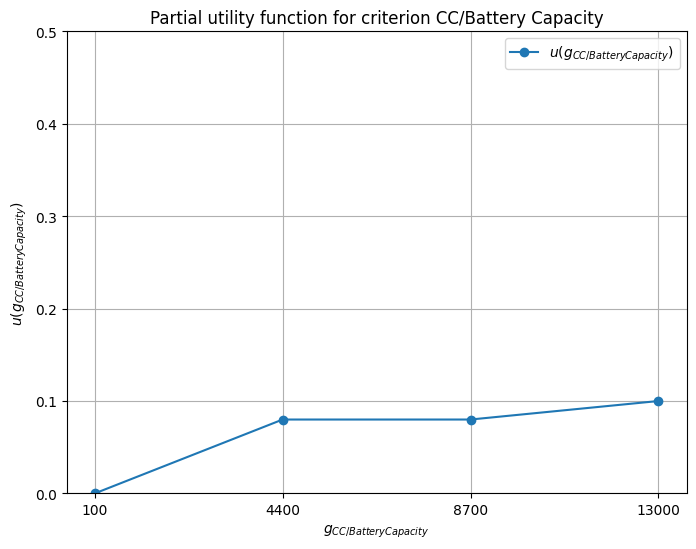

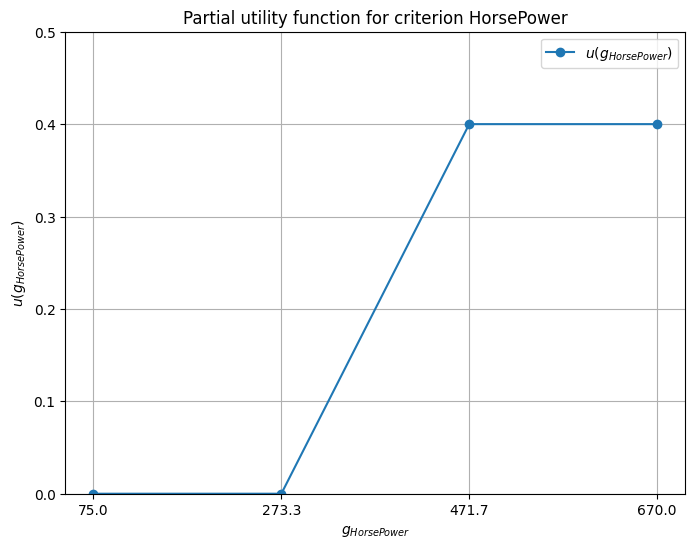

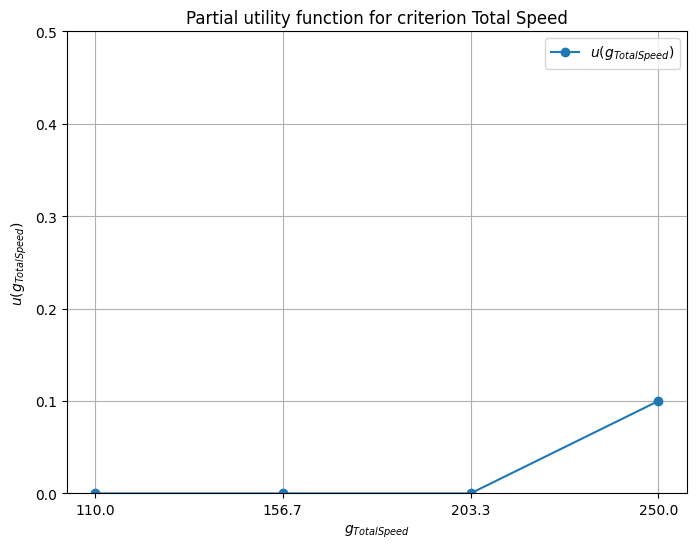

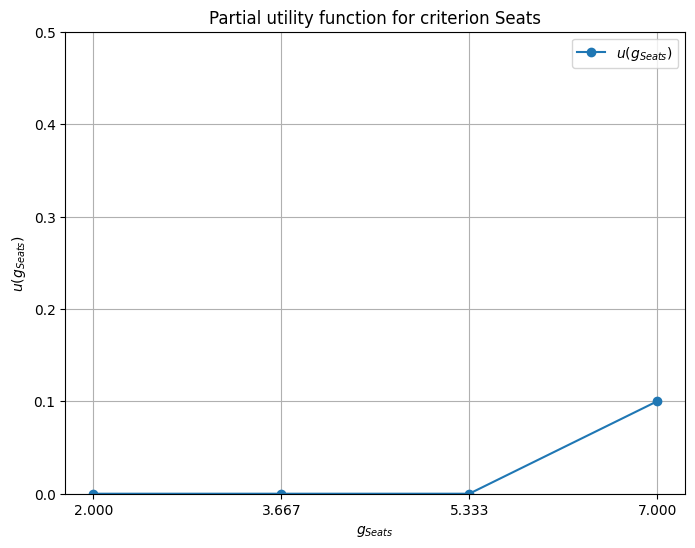

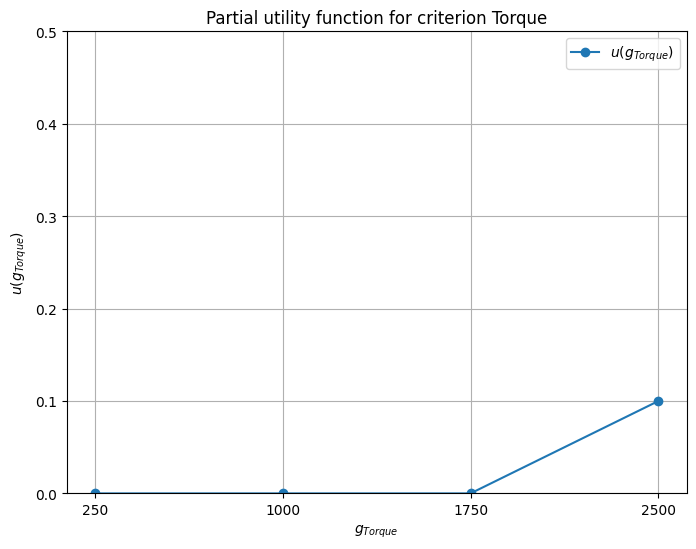

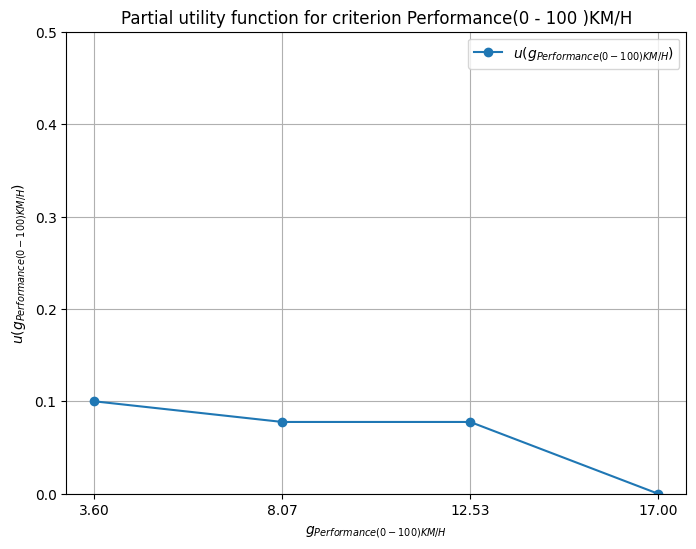

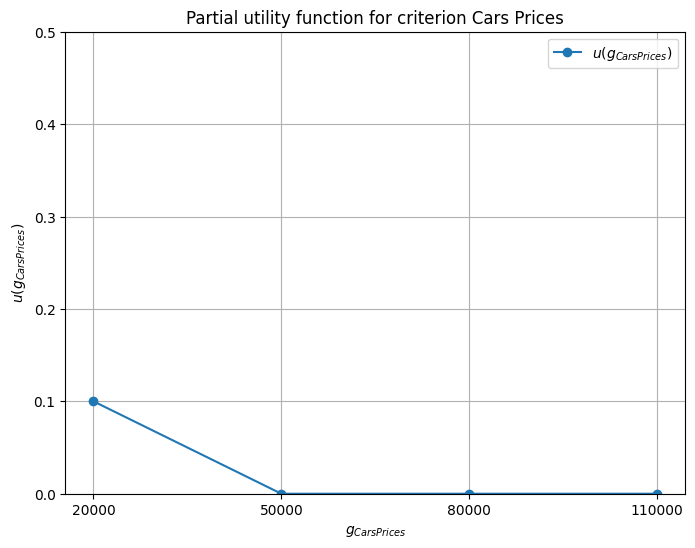

In [44]:
for criterion in criteria:
    plot_criterion(prob, u, criterion, criterion_values)

In order to compare the method with AHP we have to calcualate comprehensive utility and sort dataframe

In [45]:
def marginal_utility(c, val, u, criterion_values):
    vals = sorted(criterion_values[c])
    for j in range(len(vals)-1):
        xj = vals[j]
        xj1 = vals[j+1]
        if xj <= val <= xj1:
            return (
                value(u[c][xj]) +
                (val - xj) / (xj1 - xj) *
                (value(u[c][xj1]) - value(u[c][xj]))
            )
    return value(u[c][vals[-1]])

def comprehensive_utility(row, u, weights, criterion_values):
    return sum(value(weights[c]) * marginal_utility(c, row[c], u, criterion_values) for c in weights)

df['Utility'] = df.apply(lambda row: comprehensive_utility(row, u, weights, criterion_values), axis=1)

df_sorted = df.sort_values(by='Utility', ascending=False).reset_index(drop=True)
df_sorted

,Company Names,Cars Names,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Seats,Torque,Utility
0,Tesla,Model X,100,670,250,3.8,98490,7,967,0.189900
1,BMW,M550i XDRIVE,4395,523,250,3.6,78000,5,650,0.187988
2,Volvo,Volvo FMX,13000,500,110,16.5,110000,2,2500,0.180869
3,Volvo,Volvo VNR,12800,400,110,17.0,95000,2,1800,0.112758
4,TOYOTA,GR COROLLA,1618,300,230,5.0,36995,5,370,0.043685
5,Volkswagen,Golf 4MOTION,1968,150,250,4.9,40000,5,400,0.026158
6,TOYOTA,INNOVA HYCROSS,1987,184,165,9.5,40000,7,250,0.024610
7,Volkswagen,Passat,1984,150,210,7.8,25000,5,250,0.021166
8,Volkswagen,Polo TDI,1390,75,190,9.9,20000,5,250,0.020166
9,Volkswagen,Jetta Hybrid,1395,170,210,8.6,28000,5,250,0.018937
